<a href="https://colab.research.google.com/github/Abidullha/ReX-GNN/blob/main/ReX_GNN_Setup.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📦 Environment Setup: PyTorch + PyG

In [3]:
import torch
print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())


PyTorch version: 2.6.0+cu124
GPU available: True


Install PyG

In [4]:
# PyG install command (if needed)
!pip install torch-geometric -q

# 🔢 Python Libraries: NumPy, Pandas, Matplotlib

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

traffic = np.array([100, 130, 150, 140, 110])
moving_avg = np.convolve(traffic, np.ones(3)/3, mode='valid')
print("Moving Average:", moving_avg)


Moving Average: [126.66666667 140.         133.33333333]


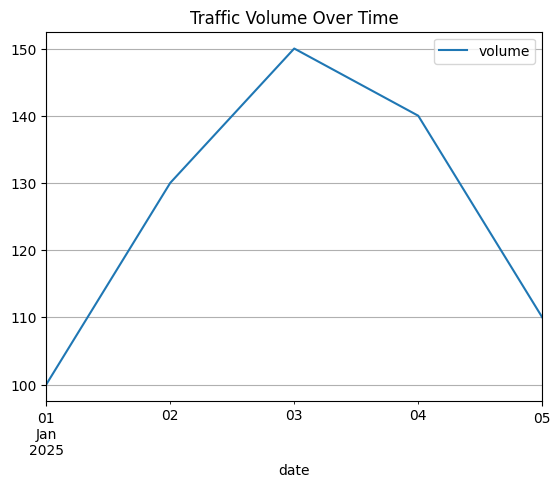

In [6]:
# Time-series plot
dates = pd.date_range("2025-01-01", periods=5)
df = pd.DataFrame({'date': dates, 'volume': traffic}).set_index('date')
df.plot()
plt.title("Traffic Volume Over Time")
plt.grid(True)
plt.show()


# 🔗 Graph Construction with PyTorch Geometric


In [8]:
from torch_geometric.data import Data

x = torch.tensor([[60, 100], [45, 130], [50, 120], [70, 80]], dtype=torch.float)
edge_index = torch.tensor([[0, 1, 2, 3, 0], [1, 2, 3, 0, 2]], dtype=torch.long)
edge_attr = torch.tensor([[1.0], [0.5], [1.2], [0.7], [0.9]], dtype=torch.float)

graph = Data(x=x, edge_index=edge_index, edge_attr=edge_attr)
print(graph)


Data(x=[4, 2], edge_index=[2, 5], edge_attr=[5, 1])


# 🤖 Mini Regression: Predicting Traffic Volume from Hour


In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

X = np.array([[i] for i in range(24)])
y = np.array([80, 60, 40, 30, 25, 20, 30, 60, 120, 150, 160, 170,
              180, 190, 170, 160, 140, 130, 110, 100, 90, 100, 120, 100])

X_train, X_test = X[:19], X[19:]
y_train, y_test = y[:19], y[19:]

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

print(f"MAE: {mae:.2f}, RMSE: {rmse:.2f}")


MAE: 97.74, RMSE: 98.37


## Notes:
- Trained a linear regression model on simple hourly traffic data
- Metrics like MAE and RMSE show prediction error
- These metrics will be used to evaluate ReX-GNN vs baselines
